# 01 — Khám phá bộ dữ liệu công khai xLAM (2.000 hàng gốc)

**Nhiệm vụ ClickUp:** Tuần 1 — Dựng môi trường và khám phá bộ dữ liệu công khai xLAM (2k hàng gốc)

**Mục tiêu:** chạy được notebook này trên Colab (hoặc máy cá nhân) từ file đã có sẵn trong repo
`data/public/xlam_raw_2k.jsonl` — **không cần tải gì thêm, không cần token** — và hiểu một hàng dữ liệu
tool-calling gồm những gì. Ô cuối **Tạo báo cáo** in ra khối Markdown: copy và dán vào comment của task trên ClickUp.

Cách chạy: `Runtime → Run all`. Ô nào lỗi thì đọc thông báo, sửa, chạy lại ô đó rồi tiếp tục.
Trên Colab cần secret `GITHUB_TOKEN` (xem `notebooks/README.md`).

In [ ]:
# --- Thiết lập (Colab + local) --------------------------------------------------------------
# Colab : read GITHUB_TOKEN from Secrets, clone the private repo (skip if present), chdir into it.
# Local : walk up from the current directory until the repo root (docs/contracts/cli.md) is found.
# Sets REPO (Path), GIT_SHA, IN_COLAB, AUTHOR and a run() helper that calls repo scripts.
import os, shlex, subprocess, sys
from pathlib import Path

REPO_HTTPS = "github.com/thanhhao98/ChatSystem"
MARKER = "docs/contracts/cli.md"          # exists at the root of every checkout

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
IN_KAGGLE = bool(os.environ.get("KAGGLE_KERNEL_RUN_TYPE"))


def _github_token():
    # Colab Secrets -> Kaggle Secrets -> environment variable. Never print the value.
    if IN_COLAB:
        from google.colab import userdata
        return userdata.get("GITHUB_TOKEN")
    if IN_KAGGLE:
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("GITHUB_TOKEN")
    return os.environ["GITHUB_TOKEN"]


if IN_COLAB or IN_KAGGLE:
    try:
        _token = _github_token()
    except Exception as e:  # SecretNotFoundError / NotebookAccessError / KeyError
        raise RuntimeError(
            "Thiếu secret GITHUB_TOKEN. Colab: biểu tượng chìa khoá (Secrets) -> Add new secret: "
            "Name = GITHUB_TOKEN, Value = Personal access token (classic, scope repo) của tài khoản collaborator "
            "trên thanhhao98/ChatSystem, bật 'Notebook access'. Kaggle: Add-ons -> Secrets -> GITHUB_TOKEN. "
            "Rồi chạy lại ô này.") from e
    if not Path("ChatSystem").exists():
        _r = subprocess.run(["git", "clone", "--quiet", f"https://{_token}@{REPO_HTTPS}", "ChatSystem"],
                            capture_output=True, text=True)
        if _r.returncode != 0:
            raise RuntimeError("git clone thất bại: " + _r.stderr.replace(_token, "<token>"))
    os.chdir("ChatSystem")
    del _token
else:
    _here = Path.cwd().resolve()
    for _cand in [_here, *_here.parents]:
        if (_cand / MARKER).exists():
            os.chdir(_cand)
            break
    else:
        raise FileNotFoundError(f"Không tìm thấy gốc repo (không có {MARKER}) khi đi lên từ {_here}. "
                                "Mở notebook từ bên trong thư mục ChatSystem đã clone.")

REPO = Path.cwd()


def _git(*args):
    # Small helper: run a git command in REPO and return stdout ("" on any failure).
    try:
        return subprocess.run(["git", *args], cwd=REPO, capture_output=True, text=True).stdout.strip()
    except OSError:
        return ""


GIT_SHA = _git("rev-parse", "--short", "HEAD") or "no-git"
AUTHOR = os.environ.get("GITHUB_USER") or _git("config", "user.name") or "điền tên"


def run(cmd):
    # Run a repo script (list of args), echo the command, stream its output, return CompletedProcess.
    shown = " ".join(shlex.quote(c) for c in cmd).replace(shlex.quote(sys.executable), "python", 1)
    print("$ " + shown)
    p = subprocess.run(cmd, cwd=REPO, capture_output=True, text=True)
    if p.stdout:
        print(p.stdout.rstrip())
    if p.stderr:
        print(p.stderr.rstrip())
    print(f"[exit code = {p.returncode}]")
    return p


print(f"REPO      = {REPO}")
print(f"git HEAD  = {GIT_SHA}")
print(f"python    = {sys.version.split()[0]} · Colab = {IN_COLAB} · Kaggle = {IN_KAGGLE} · author = {AUTHOR}")

REPO      = /content/ChatSystem/ChatSystem
git HEAD  = 0e9317e
python    = 3.13.15 · Colab = True · Kaggle = False · author = điền tên


## Bộ dữ liệu xLAM là gì?

`Salesforce/xlam-function-calling-60k` (APIGen, arXiv:2406.18518) gồm 60.000 mẫu tool-calling do Salesforce sinh
và kiểm định tự động. Repo này chỉ giữ một lát **2.000 hàng** đã lọc: đúng 1 lời gọi vàng, 1–4 tool mỗi hàng,
lấy mẫu phân tầng theo số tool, `seed 20260913` (cách tạo: `scripts/recover_xlam_raw.py`).

Mỗi hàng là một dòng JSON trong file `.jsonl` với 4 trường:

| Trường | Ý nghĩa |
|---|---|
| `id` | mã hàng dạng `xlam-xxxxxxxx`, ổn định, dùng để truy vết |
| `query` | câu yêu cầu của người dùng (tiếng Anh) |
| `tools` | danh sách tool **được cung cấp** cho mẫu: `{name, description, parameters: {tên_tham_số: {type, description, default?}}}` |
| `answers` | lời gọi **vàng** (gold): `[{name, arguments: {...}}]` — tool đúng + tham số đúng |

Mô hình phải học: đọc `query` + `tools` → sinh ra đúng `answers`. Trong bản phát hành gốc trên Hugging Face,
`tools` và `answers` là **chuỗi JSON** (phải `json.loads`); trong lát 2k của repo chúng đã là list. Code bên dưới chấp nhận cả hai.

**Giấy phép & ghi công:** dữ liệu gốc phát hành theo **CC-BY-4.0** — được dùng, sửa, phân phối lại nhưng phải ghi nguồn:
*Liu et al., "APIGen: Automated Pipeline for Generating Verifiable and Diverse Function-Calling Datasets" (2024), arXiv:2406.18518;
dataset `Salesforce/xlam-function-calling-60k`.* Chi tiết trong `data/public/ATTRIBUTION.md`.

## Đọc dữ liệu

In [ ]:
# Load the 2,000 raw rows (one JSON object per line).
import json
from collections import Counter
from statistics import median

RAW_PATH = REPO / "data/public/xlam_raw_2k.jsonl"
rows = [json.loads(line) for line in RAW_PATH.open(encoding="utf-8") if line.strip()]
print(f"rows = {len(rows)}")
print("keys of row 0:", list(rows[0].keys()))
assert len(rows) == 2000, "Lát dữ liệu phải có đúng 2000 hàng — kiểm tra lại file"

rows = 2000
keys of row 0: ['id', 'query', 'tools', 'answers']


## Thống kê cơ bản

In [ ]:
# Basic statistics. tools/answers may be JSON strings (original HF release) or lists (this slice).
def as_obj(x):
    return json.loads(x) if isinstance(x, str) else x


def mmm(values):
    # min / median / max in one short string
    return f"min={min(values)} median={median(values):g} max={max(values)}"


tools_per_row = [len(as_obj(r["tools"])) for r in rows]
calls_per_row = [len(as_obj(r["answers"])) for r in rows]
args_per_call = [len(a.get("arguments") or {}) for r in rows for a in as_obj(r["answers"])]
query_len = [len(r["query"]) for r in rows]


def answers_parse_ok(r):
    # True when answers is (or parses to) a non-empty list of {name: str, arguments: dict}
    try:
        ans = as_obj(r["answers"])
    except (TypeError, json.JSONDecodeError):
        return False
    return isinstance(ans, list) and len(ans) > 0 and all(
        isinstance(a, dict) and isinstance(a.get("name"), str) and isinstance(a.get("arguments", {}), dict)
        for a in ans)


json_ok = sum(answers_parse_ok(r) for r in rows)

STATS = {
    "rows": len(rows),
    "tools_per_row": mmm(tools_per_row),
    "calls_per_row": mmm(calls_per_row),
    "args_per_call": mmm(args_per_call),
    "query_len_chars": mmm(query_len),
    "answers_json_ok": f"{json_ok}/{len(rows)}",
}
for k, v in STATS.items():
    print(f"{k:18s} {v}")
print("tools/row distribution:", dict(sorted(Counter(tools_per_row).items())))

rows               2000
tools_per_row      min=1 median=2 max=4
calls_per_row      min=1 median=1 max=1
args_per_call      min=0 median=2 max=12
query_len_chars    min=19 median=79 max=574
answers_json_ok    2000/2000
tools/row distribution: {1: 644, 2: 372, 3: 465, 4: 519}


## Top-20 tool được gọi nhiều nhất

In [ ]:
# Which tools are called most often (gold answers), and how many distinct tools exist?
gold_names = Counter(a["name"] for r in rows for a in as_obj(r["answers"]))
offered_names = Counter(t["name"] for r in rows for t in as_obj(r["tools"]))
print(f"distinct tools offered: {len(offered_names)} | distinct tools called (gold): {len(gold_names)}")

TOP20 = gold_names.most_common(20)
print("\nTop-20 tool names (gold calls):")
for i, (name, n) in enumerate(TOP20, 1):
    print(f"{i:2d}. {name:45s} {n}")

distinct tools offered: 1835 | distinct tools called (gold): 992

Top-20 tool names (gold calls):
 1. search                                        35
 2. calculate_investment_return                   16
 3. project_investment_growth                     15
 4. linear_regression_prediction                  14
 5. future_investment_value                       13
 6. simulate_query_database                       12
 7. least_common_multiple                         12
 8. get_city_from_zipcode                         11
 9. compound_interest                             11
10. cell_density                                  10
11. calculate_electric_field                      10
12. find_kth_smallest_number                      9
13. min_meeting_rooms                             9
14. std_deviation                                 9
15. euclidean_distance                            9
16. loginuser                                     9
17. california_alimony                            9
18. pro

## Hai biểu đồ nhỏ

Trái: số tool mỗi hàng (1–4). Phải: phân bố độ dài `query` theo ký tự.

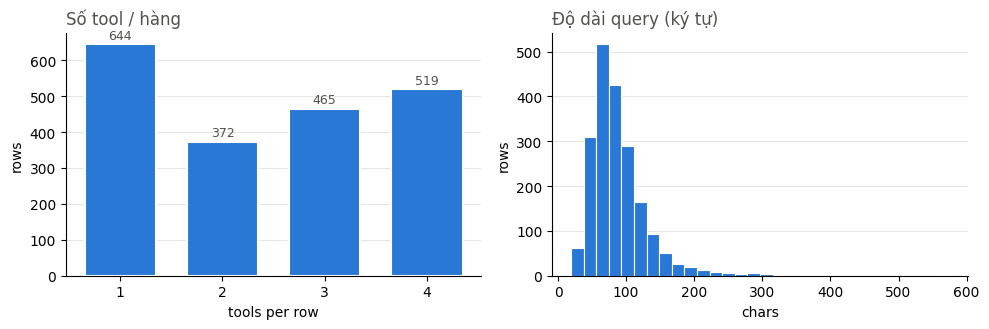

In [ ]:
# Two small single-series plots. matplotlib is preinstalled on Colab; guard the import for bare environments.
try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None
    print("matplotlib chưa cài -> bỏ qua biểu đồ (local: pip install matplotlib).")

if plt is not None:
    BLUE, INK, GRID = "#2a78d6", "#52514e", "#e5e5e2"
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))

    # Left: tools per row is discrete (1..4) -> bars with direct labels
    dist = Counter(tools_per_row)
    xs = sorted(dist)
    ax = axes[0]
    bars = ax.bar(xs, [dist[x] for x in xs], color=BLUE, width=0.7, edgecolor="white", linewidth=1.5)
    ax.bar_label(bars, padding=2, color=INK, fontsize=9)
    ax.set_xticks(xs)
    ax.set_title("Số tool / hàng", loc="left", color=INK)
    ax.set_xlabel("tools per row")
    ax.set_ylabel("rows")

    # Right: query length in characters -> histogram
    ax = axes[1]
    ax.hist(query_len, bins=30, color=BLUE, edgecolor="white", linewidth=0.8)
    ax.set_title("Độ dài query (ký tự)", loc="left", color=INK)
    ax.set_xlabel("chars")
    ax.set_ylabel("rows")

    for ax in axes:  # recessive axes and grid
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(axis="y", color=GRID, linewidth=0.8)
        ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()

## Xem 3 hàng ví dụ

In [ ]:
# Three raw examples; tool descriptions are shortened so the cell stays readable.
def short(r, width=160):
    tools = [{"name": t["name"],
              "description": (t.get("description") or "")[:width],
              "parameters": list((t.get("parameters") or {}).keys())} for t in as_obj(r["tools"])]
    return {"id": r["id"], "query": r["query"], "tools": tools, "answers": as_obj(r["answers"])}


for r in rows[:3]:
    print(json.dumps(short(r), ensure_ascii=False, indent=1))
    print("-" * 80)

{
 "id": "xlam-0053460a",
 "query": "What are the subcontrols associated with the control 'AC-1'?",
 "tools": [
  {
   "name": "geogrid_seach_with_ranking",
   "description": "Perform a full grid search and retrieve the ranking of a business at every coordinate point in the grid. The grid cells in the results are ordered left-to-right",
   "parameters": [
    "match_value",
    "query",
    "lng",
    "lat",
    "zoom",
    "match_type",
    "distance_unit",
    "width",
    "height",
    "grid_size",
    "distance"
   ]
  },
  {
   "name": "get_subcontrol_by_control",
   "description": "Fetches all subcontrols or CCIs associated with a specified control.",
   "parameters": [
    "control"
   ]
  },
  {
   "name": "get_country_population",
   "description": "Fetch the population data for a given country using the Toolbench RapidAPI service.",
   "parameters": [
    "country"
   ]
  }
 ],
 "answers": [
  {
   "name": "get_subcontrol_by_control",
   "arguments": {
    "control": "AC-1"
 

## Bước nâng cao (không bắt buộc): tải bản đầy đủ 60k từ Hugging Face

Bộ gốc là **gated**: phải đăng nhập Hugging Face và bấm chấp nhận điều khoản. Cách làm:

1. Mở https://huggingface.co/datasets/Salesforce/xlam-function-calling-60k → bấm **Agree and access repository**.
2. `Settings → Access Tokens` → tạo token loại *Read*.
3. Colab → biểu tượng chìa khoá (Secrets) → thêm `HF_TOKEN` (chỉ để trong Secrets, **không** dán vào code hay commit).
4. Đổi `RUN_ADVANCED = True` rồi chạy ô dưới. Tải ~60k hàng mất vài phút.

In [ ]:
# Optional gated download. Off by default so "Run all" stays fast and needs no token.
RUN_ADVANCED = False  # change to True to try it

if RUN_ADVANCED:
    hf_token = None
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN")
    except Exception:
        hf_token = os.environ.get("HF_TOKEN")
    try:
        from datasets import load_dataset
        full = load_dataset("Salesforce/xlam-function-calling-60k", split="train", token=hf_token)
        print(full)
        print("row 0 keys:", list(full[0].keys()))
    except Exception as e:
        print(f"Không tải được ({type(e).__name__}): {str(e)[:400]}")
        print("Hướng dẫn: (1) đăng nhập huggingface.co và bấm 'Agree and access repository' trên trang dataset; "
              "(2) tạo token Read tại Settings -> Access Tokens; (3) Colab -> Secrets -> HF_TOKEN; "
              "(4) nếu thiếu thư viện: pip install datasets; rồi chạy lại ô này.")
else:
    print("Bỏ qua bước nâng cao (RUN_ADVANCED = False).")

Bỏ qua bước nâng cao (RUN_ADVANCED = False).


## Tạo báo cáo

Copy toàn bộ khối in ra bên dưới (từ dòng `## Báo cáo …`) và dán vào **comment** của task trên ClickUp.
Thay `điền tên` bằng GitHub username của bạn nếu notebook không tự nhận ra.

In [ ]:
# Print the ClickUp comment block with exactly the numbers the task's acceptance criteria ask for.
import datetime

TASK = "Tuần 1 — Dựng môi trường và khám phá bộ dữ liệu công khai xLAM (2k hàng gốc)"
lines = [
    f"## Báo cáo {TASK} — {datetime.date.today().isoformat()} — {AUTHOR}",
    f"- Notebook: `notebooks/data/01_explore_public_dataset.ipynb` @ `{GIT_SHA}` · môi trường: {'Colab' if IN_COLAB else 'local'}",
    f"- File: `data/public/xlam_raw_2k.jsonl` · rows = **{STATS['rows']}**",
    f"- tools/row: {STATS['tools_per_row']}",
    f"- calls/row: {STATS['calls_per_row']}",
    f"- args/call: {STATS['args_per_call']}",
    f"- query length (chars): {STATS['query_len_chars']}",
    f"- answers parse as JSON: {STATS['answers_json_ok']}",
    f"- distinct tools offered / called: {len(offered_names)} / {len(gold_names)}",
    "- Top-20 tool names (gold): " + ", ".join(f"`{n}` ({c})" for n, c in TOP20),
    "- Bước nâng cao (tải bản 60k): " + ("đã thử" if RUN_ADVANCED else "không làm"),
]
print("\n".join(lines))

## Báo cáo Tuần 1 — Dựng môi trường và khám phá bộ dữ liệu công khai xLAM (2k hàng gốc) — 2026-09-14 — điền tên
- Notebook: `notebooks/data/01_explore_public_dataset.ipynb` @ `0e9317e` · môi trường: Colab
- File: `data/public/xlam_raw_2k.jsonl` · rows = **2000**
- tools/row: min=1 median=2 max=4
- calls/row: min=1 median=1 max=1
- args/call: min=0 median=2 max=12
- query length (chars): min=19 median=79 max=574
- answers parse as JSON: 2000/2000
- distinct tools offered / called: 1835 / 992
- Top-20 tool names (gold): `search` (35), `calculate_investment_return` (16), `project_investment_growth` (15), `linear_regression_prediction` (14), `future_investment_value` (13), `simulate_query_database` (12), `least_common_multiple` (12), `get_city_from_zipcode` (11), `compound_interest` (11), `cell_density` (10), `calculate_electric_field` (10), `find_kth_smallest_number` (9), `min_meeting_rooms` (9), `std_deviation` (9), `euclidean_distance` (9), `loginuser` (9), `california_alimony` (9), `pr